# 🚕 RidePulse — Ride-Sharing Revenue & Operations Intelligence



##### This notebook explores the Uber Ride Analytics dataset to understand ride demand, revenue, cancellations, vehicle performance, customer behavior, and operational patterns . 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("ncr_ride_bookings.csv")

#### Basic Dataset Information

In [8]:
df.info()    #Shows column names, data types, non-null values, and memory usage

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  1050

#### Check Dataset Dimensions

In [9]:
df.shape  # Returns (number of rows, number of columns)

(150000, 21)

#### Missing Values

In [10]:
df.isnull().sum()  # Counts missing values in every column

Date                                      0
Time                                      0
Booking ID                                0
Booking Status                            0
Customer ID                               0
Vehicle Type                              0
Pickup Location                           0
Drop Location                             0
Avg VTAT                              10500
Avg CTAT                              48000
Cancelled Rides by Customer          139500
Reason for cancelling by Customer    139500
Cancelled Rides by Driver            123000
Driver Cancellation Reason           123000
Incomplete Rides                     141000
Incomplete Rides Reason              141000
Booking Value                         48000
Ride Distance                         48000
Driver Ratings                        57000
Customer Rating                       57000
Payment Method                        48000
dtype: int64

#### Check Duplicate Rows

In [11]:
df.duplicated().sum()  # Count completely duplicated rows

np.int64(0)

#### Check Duplicate Booking IDs

In [12]:
df["Booking ID"].duplicated().sum()  # Check whether any Booking IDs are repeated

np.int64(1233)

In [13]:
df["Booking ID"].nunique()  # Count the number of unique Booking IDs

148767

## Categorical Data Exploration

#### Booking Status

In [14]:
df["Booking Status"].value_counts()  # Count bookings by status

Booking Status
Completed                93000
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Incomplete                9000
Name: count, dtype: int64

#### Vehicle Types

In [15]:
df["Vehicle Type"].value_counts()  # Count bookings for each vehicle type

Vehicle Type
Auto             37419
Go Mini          29806
Go Sedan         27141
Bike             22517
Premier Sedan    18111
eBike            10557
Uber XL           4449
Name: count, dtype: int64

#### Payment Methods

In [16]:
df["Payment Method"].value_counts()  # Count bookings by payment method

Payment Method
UPI            45909
Cash           25367
Uber Wallet    12276
Credit Card    10209
Debit Card      8239
Name: count, dtype: int64

#### Pickup Locations

In [17]:
df["Pickup Location"].nunique()  # Count unique pickup locations

176

## Date & Time Exploration

#### Check Date Format

In [18]:
df["Date"].head()  # Display a few values from the Date column

0    2024-03-23
1    2024-11-29
2    2024-08-23
3    2024-10-21
4    2024-09-16
Name: Date, dtype: object

In [19]:
df["Date"] = pd.to_datetime(
    df["Date"],
    errors="coerce"
)  # Convert Date into Pandas datetime format; invalid values become NaT

In [20]:
df["Date"].dtype  # Confirm that Date is now a datetime column

dtype('<M8[ns]')

#### Check Time Format

In [21]:
df["Time"].head()  # Display a few booking times

0    12:29:38
1    18:01:39
2    08:56:10
3    17:17:25
4    22:08:00
Name: Time, dtype: object

#### Date Range 

In [23]:
print("First booking date:", df["Date"].min())  # Find earliest booking date
print("Last booking date:", df["Date"].max())   # Find latest booking date

First booking date: 2024-01-01 00:00:00
Last booking date: 2024-12-30 00:00:00


## Numerical Columns

#### Booking Value

In [25]:
df["Booking Value"].describe()  # Summary statistics for booking/fare value

count    102000.000000
mean        508.295912
std         395.805774
min          50.000000
25%         234.000000
50%         414.000000
75%         689.000000
max        4277.000000
Name: Booking Value, dtype: float64

#### Ride Distance

In [26]:
df["Ride Distance"].describe()  # Summary statistics for ride distance

count    102000.000000
mean         24.637012
std          14.002138
min           1.000000
25%          12.460000
50%          23.720000
75%          36.820000
max          50.000000
Name: Ride Distance, dtype: float64

#### Ratings

In [27]:
df["Driver Ratings"].describe()  # Summary statistics for driver ratings

count    93000.000000
mean         4.230992
std          0.436871
min          3.000000
25%          4.100000
50%          4.300000
75%          4.600000
max          5.000000
Name: Driver Ratings, dtype: float64

### Negative Booking Values

In [29]:
(df["Booking Value"] < 0).sum()  # Count bookings with negative fare values

np.int64(0)

## Basic Visualization

#### Booking Status Chart

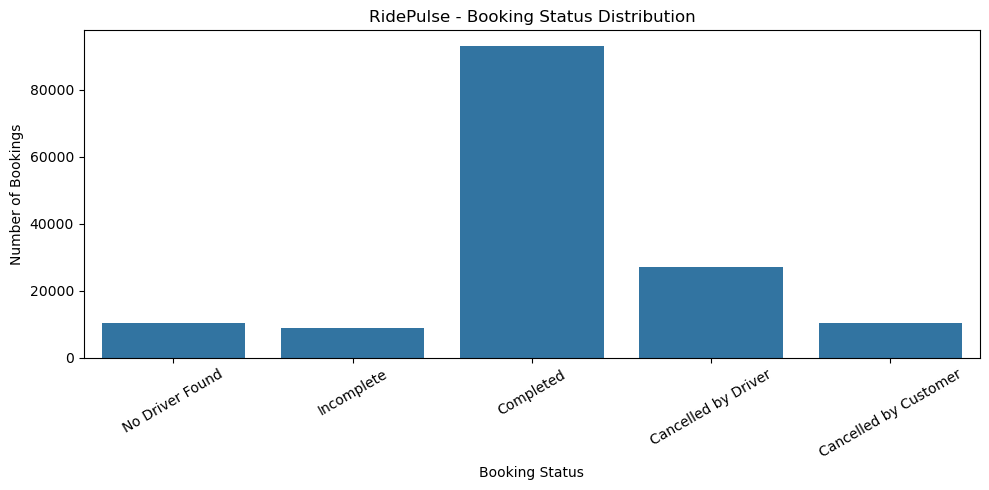

In [30]:
plt.figure(figsize=(10, 5))  # Set the chart size

sns.countplot(
    data=df,
    x="Booking Status"
)  # Create a bar chart showing number of bookings by status

plt.title("RidePulse - Booking Status Distribution")  # Add chart title
plt.xlabel("Booking Status")                        # Label x-axis
plt.ylabel("Number of Bookings")                    # Label y-axis
plt.xticks(rotation=30)                              # Rotate labels for readability
plt.tight_layout()                                   # Prevent labels from being cut off
plt.show()                                           # Display the chart

#### Vehicle Type Chart

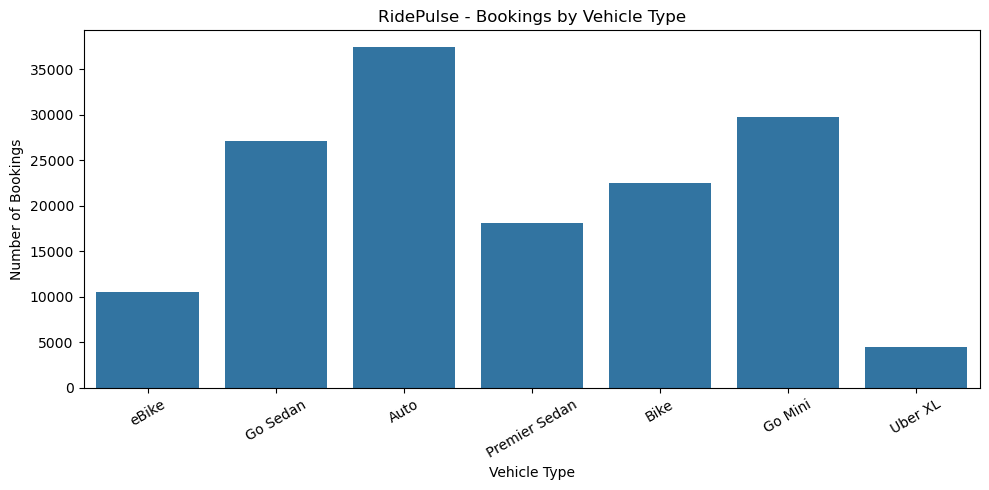

In [31]:
plt.figure(figsize=(10, 5))  # Set chart size

sns.countplot(
    data=df,
    x="Vehicle Type"
)  # Count bookings for each vehicle type

plt.title("RidePulse - Bookings by Vehicle Type")  # Add chart title
plt.xlabel("Vehicle Type")                        # Label x-axis
plt.ylabel("Number of Bookings")                  # Label y-axis
plt.xticks(rotation=30)                            # Rotate vehicle names
plt.tight_layout()                                 # Adjust layout
plt.show()                                         # Display chart